# **Sesión 4:** Procesamiento de imagenes y extracción de características

## **Librerías**

In [148]:
# ! pip install tqdm scikit-learn pandas openpyxl

Solamente si lo anterior no funciona ejecutar esta opción

In [149]:
# import sys
# !{sys.executable} -m pip install tqdm scikit-learn pandas openpyxl

In [150]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from utils import *
from bow import BoW
from dataset import Dataset
from image_classifier import ImageClassifier
import time
from tqdm import tqdm
import sys
import pickle
import os
import glob

In [151]:
def show_image(img):
    cv2.imshow("Image", img)
    cv2.waitKey()
    cv2.destroyAllWindows()
    
def write_image(img, filename="img.jpg"):
    cv2.imwrite(filename, img)
    
def load_images(filenames):
    return [cv2.imread(filename) for filename in filenames]

base_path = os.path.join(os.getcwd(), "../data/partB/*")

gb_path = glob.glob(base_path)

# **Apartado B**: Detección de puntos de interés y bolsa de palabras

## **B1: Detección de puntos de interés**

### **Tarea B.1**: Generar función de filtro gaussiano

Se generará a partir de la imagen de la carpeta `data/partB` las imágenes con el filtrado gaussiano. Para ello se empleará la función `generateGaussianImages()` que tiene que desarrollar empleando la función [`cv2.GaussianBlur()`](https://docs.opencv.org/4.x/d4/d86/group__imgproc__filter.html#gae8bdcd9154ed5ca3cbc1766d960f45c1). Es recomendble visualizar los resultados para comprobar el funcionamiento. Para ello convierta los datos de la imagen a visualizar a `np.uint8`

In [152]:
def generateGaussianImages(image, sigmas):
    """Generate the gaussian images using the base image and the sigmas given

    Args:
        image (np.array[np.float32]): Base image to blur
        sigmas (List[np.float32]): Sigmas for blurring the image 

    Returns:
        List[np.array[np.float32]: List of blurred images
    """
    gaussian_images = []

    # TODO: Generate the list of blurred images using cv2.GaussianBlur()
    for sigma in sigmas:
        if (int(8*sigma)+1) % 2 == 0:
            image = cv2.GaussianBlur(image, (int(8*sigma), int(8*sigma)), sigma)
        else:
            image = cv2.GaussianBlur(image, (int(8*sigma)+1, int(8*sigma)+1), sigma)
        gaussian_images.append(image)
    
    return gaussian_images
    

### **Tarea B.2**: Generación de espacio de escalas con imágenes gaussianas

Empleando la función anterior, complete la siguiente celda para generar las imágenes gaussianas

In [153]:
images = load_images(gb_path)
gray_imgs = []
for image in images:
    gray_imgs.append(cv2.cvtColor(image, cv2.COLOR_BGR2GRAY))

In [154]:
#TODO: Load the image in grayscale
image = gray_imgs[0]
image = image.astype(np.float32)
# Number of diference of gaussians to generate (minimum 3)
# TODO: Adjust this number to make sure keypoints are generated
intervals = 5
# Initial sigma
sigma = 1.6
# We get the necessary sigmas from the given method generateGaussianSigmas()
sigmas = generateGaussianSigmas(sigma, intervals)

#TODO: Generate the gaussian images
gaussian_images = generateGaussianImages(image, sigmas)

# for i in range(len(gaussian_images)):
#     show_image(gaussian_images[i].astype(np.uint8))

### **Tarea B.3**: Generación de diferencias de gaussianas

Utilizando la lista de imágenes gaussianas se generará una lista con las diferencias entre pares consegutivos. Para ello se empleará la función `generateDoGImages()` que tiene que desarrollar empleando la función [`cv2.subtract()`](https://docs.opencv.org/4.x/d2/de8/group__core__array.html#gaa0f00d98b4b5edeaeb7b8333b2de353b)

In [155]:
def generateDoGImages(gaussian_images):
    """Generate Difference-of-Gaussians list

    Args:
        gaussian_images (List[np.array[np.float32]): List of blurred images

    Returns:
        List[np.array[np.float32]: List of difference of gaussian images
    """
    dog_images = []

    # TODO: Generate the list of difference of gaussians using cv2.subtract()
    for i in range(len(gaussian_images)-1):
        dog_img = cv2.subtract(gaussian_images[i], gaussian_images[i+1])
        dog_images.append(dog_img) 
    
    return dog_images

dog_images = generateDoGImages(gaussian_images)

### **Tarea B.4**: Evaluación de extremos

La función `isPixelAnExtremum()` debe evaluar si el pixel central del bloque compuesto por las regiones de las 3 imágenes es un máximo o mínimo entre ellos. Como prevención, tenga en cuenta que puede tomar valores positivos y negativos

In [156]:
def isPixelAnExtremum(first_subimage, second_subimage, third_subimage, threshold):
    """Return True if the center element of the 3x3x3 array composed of subimages is strictly greater than or less than all its neighbors, False otherwise

    Args:
        first_subimage (np.array): Patch from first gaussian
        second_subimage (np.array): Patch from second gaussian
        third_subimage (np.array): Patch from third gaussian
        threshold (float): Value threshold for the pixel

    Returns:
        Bool: True if maximum or minimum, False otherwise
    """
    extremum = False
    # TODO: Check if the center pixel value is a maximum or a minimum and if its absolute value is higher than the threshold
    check = second_subimage[1][1]
    
    maximum = True
    minimum = True
    
    for i in range(3):
        for j in range(3):
            if first_subimage[i][j] < check:
                minimum = False
            
            if first_subimage[i][j] > check:
                maximum = False
                
            if third_subimage[i][j] < check:
                minimum = False
                
            if third_subimage[i][j] > check:
                maximum = False
            
            if i != 1 and j != 1:
                if second_subimage[i][j] < check:
                    minimum = False
                    
                if second_subimage[i][j] > check:
                    maximum = False

    if (maximum or minimum) and abs(check) > threshold:
        extremum = True
    
    return extremum

In [157]:
first_subimage = np.zeros((3,3),np.float32)
third_subimage = np.zeros((3,3),np.float32)
second_subimage = np.ones((3,3),np.float32)
isPixelAnExtremum(first_subimage,second_subimage, third_subimage, 0.03)

True

### **Tarea B.5**: Localización de puntos clave y orientación de los mismos

La función `findScaleSpaceExtrema()` obtendrá los puntos clave y su orientación a partir de las gaussianas y sus diferencias empleando, entre otras, la función `isPixelAnExtremum()`. Deberá completar las partes indicadas para recorrer todos los trios de imágenes consecutivos y evaluar los píxeles necesarios de estos.

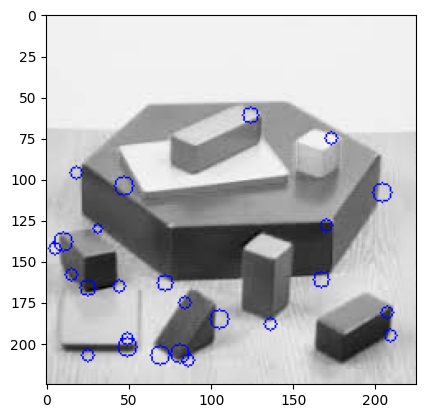

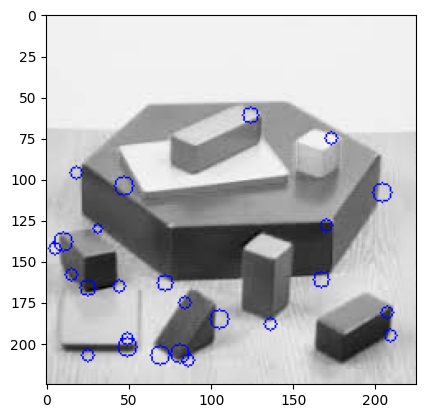

In [172]:
def findScaleSpaceExtrema(gaussian_images, dog_images, num_intervals, sigma, threshold=0.03):
    """Find pixel positions of all scale-space extrema in the image pyramid """
    keypoints = []

    # TODO: Fill the loop source data
    for image_index in range(len(dog_images)-2):
        first_image, second_image, third_image = dog_images[image_index:image_index+3]
        # (i, j) is the center of the 3x3 array
        # TODO: Fill the 2 range limits knowing you have to move the 3x3 window across the whole image
        for i in range(1, first_image.shape[0]-2):
            for j in range(1, first_image.shape[1]-2):
                # TODO: Fill the method with the required arguments
                if isPixelAnExtremum(first_image[i-1:i+2,j-1:j+2], second_image[i-1:i+2,j-1:j+2], third_image[i-1:i+2,j-1:j+2], threshold):
                    # Refine the keypoint localization
                    localization_result = localizeExtremumViaQuadraticFit(i, j, image_index + 1, num_intervals, dog_images, sigma)
                    if localization_result is not None:
                        keypoint, localized_image_index = localization_result
                        # Get the keypoint orientation
                        keypoints_with_orientations = computeKeypointsWithOrientations(keypoint, gaussian_images[localized_image_index])
                        for keypoint_with_orientation in keypoints_with_orientations:
                            keypoints.append(keypoint_with_orientation)
    return keypoints

# Keypoint Detection with Taylor Expansion and Contrast Thresholding
threshold = 0.03
keypoints = findScaleSpaceExtrema(gaussian_images, dog_images, intervals, sigma, threshold)
visualizeKp(image, keypoints)
keypoints = removeDuplicateKeypoints(keypoints)
visualizeKp(image, keypoints)

Con los puntos clave totalmente definidos y las imágenes gaussianas ya podemos obtener los descriptores con la función proporcionada de `generateDescriptors()`

In [173]:
descriptors = generateDescriptors(keypoints, gaussian_images)

### **Tarea B.6**: Pipeline de generación de puntos clave y descriptores

Complete la función con los métodos desarrollados en tareas previas para generar los puntos clave y descriptores necesarios dada una imagen, un valor de sigma y un número de diferencias de gaussianas

In [176]:
def computeKeypointsAndDescriptors(image, sigma=1.6, num_intervals=3):
    """Compute SIFT keypoints and descriptors for an input image """
    # TODO: Fill the pipeline to get the keypoint and descriptors as before
    image = image.astype('float32')
    gaussian_kernels = generateGaussianSigmas(sigma, num_intervals)
    gaussian_images = generateGaussianImages(image, sigmas)
    dog_images = generateDoGImages(gaussian_images)
    keypoints = findScaleSpaceExtrema(gaussian_images, dog_images, intervals, sigma, threshold)
    keypoints = removeDuplicateKeypoints(keypoints)
    descriptors = generateDescriptors(keypoints, gaussian_images)
    return keypoints, descriptors

### **Tarea B.7**: Correspondencia de características entre imágenes

Cargue las imágenes con `cv2` y complete la llamada a la función previa

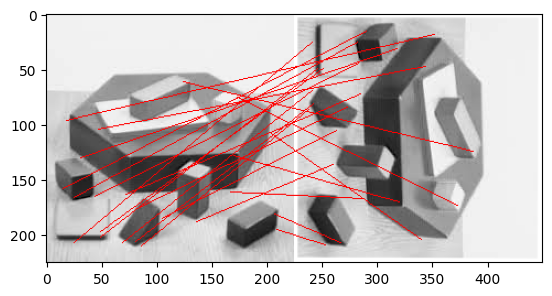

In [178]:
# TODO: Load the images with cv2 in grayscale
img1 = gray_imgs[0]
img2 = gray_imgs[1]

# TODO: Fill the function calls
kp1, des1 = computeKeypointsAndDescriptors(img1, num_intervals=5)
kp2, des2 = computeKeypointsAndDescriptors(img2, num_intervals=5)

matchFeatures(img1, kp1, des1, img2, kp2, des2)

#### **Ampliación**: SIFT con OpenCV

In [ ]:
# Load the image
image_0 = cv2.imread('../data/PartB/0.jpg', cv2.IMREAD_GRAYSCALE)
image_1 = cv2.imread('../data/PartB/0_rot.jpg', cv2.IMREAD_GRAYSCALE)

# Create a SIFT detector object
sift = cv2.SIFT_create()

# Detect keypoints and compute descriptors
keypoints_0, descriptors_0 = sift.detectAndCompute(image_0, None)
keypoints_1, descriptors_1 = sift.detectAndCompute(image_1, None)

# Draw keypoints on the image
image_with_keypoints_0 = cv2.drawKeypoints(image_0, keypoints_0, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
image_with_keypoints_1 = cv2.drawKeypoints(image_1, keypoints_1, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

plt.imshow(image_with_keypoints_0)
plt.title('Keypoints with Blob Sizes and Orientations')
plt.axis('off')
plt.show()
plt.imshow(image_with_keypoints_1)
plt.title('Keypoints with Blob Sizes and Orientations')
plt.axis('off')
plt.show()

# Initialize BFMatcher
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)

# Perform KNN matching with k=2 for ratio test
matches = bf.match(descriptors_0, descriptors_1)

# sort matches by distance
matches = sorted(matches, key = lambda x:x.distance)


# Draw the good matches
matched_image = cv2.drawMatches(image_0, keypoints_0, image_1, keypoints_1, matches[:50], None,
                                flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Display the matched features
plt.figure(figsize=(12, 6))
plt.imshow(matched_image)
plt.title("Feature Matches")
plt.axis('off')
plt.show()

### **Pregunta B1**: Correspodencia de imágenes propias y evaluación

In [ ]:
# TODO: Homework

## **B2: Bolsa de palabras**

### **Tarea B.2.1**: Carga de los datasets de entrenamiento y validación para la bolsa de palabras

Descargue el dataset desde el [`enlace en Mooodle`](https://sifo.comillas.edu/pluginfile.php/5039369/mod_page/content/8/dataset.zip), descomprimalo en \data\partB. 

Empleando el método `load()` de la clase [`Dataset`](.\dataset.py) que se le proporciona, cargue los datasets de entrenamiento y validación.

In [181]:
training_set = Dataset.load("../data/partB/training", "jpg")
validation_set = Dataset.load("../data/partB/validation", "jpg")

### **Tarea B.2.2**: Extracción de los descriptores

Para poder crear la bolsa de palabras se va a comenzar obteniendo los descriptores que serán agrupados en las distintas palabras de nuestra bolsa. Para ello complete la carga de la imagen en la ruta `path` en escala de grises y obtenga sus descriptores con los métodos apropiados de cv2. Los descriptores obtenidos se añadirán a nuestra bolsa de palabras (`words`) para después ser agrupados por palabras que representen

In [ ]:
feature_extractor = cv2.SIFT_create()

# Extract features
print("\nComputing SIFT descriptors...")
time.sleep(0.1)  # Prevents a race condition between tqdm and print statements.
descriptors = []
for path in tqdm(training_set, unit="image", file=sys.stdout):
    # TODO: Load the image from the path in grayscale
    image = cv2.imread()
    try:
        # TODO: Using the cv2 methods get the descriptors for the image
        _, descriptor = None
    except:
        print(f"WARN: Issue generating descriptor for image {path}")

    if descriptor is not None:
        descriptors.append(descriptor)

### **Tarea B.2.3**: Creación del vocabulario

Añada los descriptores a la bolsa (`words`) con el método add de la misma. Con los descriptores en la bolsa, se va a realizar el agrupamiento de los mismos por palabras para obtener un vocabulario de palabras visuales. Complete la ruta de apertura del archivo y establezca el modo de apertura en escrituria y bineario para poder guardar el vocabulario generado.

In [ ]:
# Build vocabulary
vocabulary_size = 100
iterations = 20
termination_criteria = (cv2.TERM_CRITERIA_MAX_ITER | cv2.TERM_CRITERIA_EPS, iterations, 1e-6)
words = cv2.BOWKMeansTrainer(vocabulary_size, termination_criteria)

# TODO: Add all descriptors
words.add()

time.sleep(0.1)  # Prevents a race condition between tqdm and print statements.
print("\nClustering descriptors into", vocabulary_size, "words using K-means...")
vocabulary = words.cluster()
filename=  "vocabulary.pickle"
# TODO: Open the file from above in the write and binay mode
with open() as f:
    pickle.dump(["SIFT", vocabulary], f, pickle.HIGHEST_PROTOCOL)

### **Tarea B.2.4**: Entrenamiento del clasificador

Una vez se tiene el vocabulario de palabras visuales, se va a entrenar al classificador. Para ello haga uso de la clase [BoW](./bow.py) y complete los métodos que se le indican

In [ ]:
bow = BoW()
# TODO: Especify the args for the loading method
bow.load_vocabulary()

image_classifier = ImageClassifier(bow)
# TODO: Especify the args for the training method
image_classifier.train()
classifier = "classifier"
image_classifier.save(classifier)

### **Tarea B.2.5**: Inferencia en dataset de entrenamiento
Con el modelo entrenado se procede a comprobar su desempeño con el dataset de entrenamiento. Complete los métodos indicados

In [ ]:
bow = BoW()
# TODO: Especify the args for the loading method
bow.load_vocabulary()

image_classifier = ImageClassifier(bow)
# TODO: Especify the args for the loading method
image_classifier.load()
# TODO: Especify the args for the loading method
image_classifier.predict()

### **Tarea B.2.6**: Inferencia en dataset de evaluación

A continuación se evalua el desempeño del modelo con el dataset de validación. Complete los métodos indicados

In [ ]:
bow = BoW()
# TODO: Especify the args for the loading method
bow.load_vocabulary()

image_classifier = ImageClassifier(bow)
# TODO: Especify the args for the loading method
image_classifier.load()
# TODO: Especify the args for the loading method
image_classifier.predict()

### **Pregunta B.2**: Busqueda de los mejóres parámetros. ¿Cuántas palabras uso?

In [ ]:
#TODO: Homework